<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
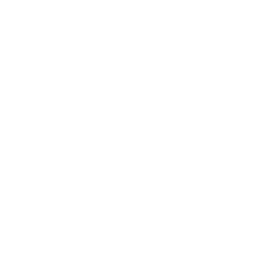
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Resource Allocation Optimization</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Education | Jenner Analytics Ltd &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This notebook optimizes seat capacity and program-level
budget allocation for a university facing a flat
operating budget and shifting enrollment demand.
PROC OPTMODEL formulates a mixed-integer linear program
that maximizes weighted student outcomes (completion
rate and post-graduation earnings) subject to a total
budget, accreditation seat minimums, and a per-program
growth cap.

> **Key finding:** Holding total instructional spend at
> the \$25.0M budget, the optimizer expands Health
> Sciences seats by 30% and STEM by 7% to meet
> forecasted demand, while trimming Liberal Arts by 29%
> and Fine Arts by 38% toward their accreditation
> floors. Health Sciences' budget share rises to 30%
> and STEM holds the largest share at 38%. The
> reallocation lifts the demand-served completion rate
> from 61.2% to 62.0% and average graduate earnings by
> roughly \$1,200, with no increase in total
> expenditure.

## Data Sources

| Source | Description | Records | Refresh |
|--------|-------------|--------:|--------:|
| IPEDS Finance | Revenue and expenditure by function | 8 years | Annual |
| IPEDS Human Resources | Faculty FTE and compensation by program | 4,200 schools | Annual |
| IPEDS Completions | Awards by CIP, enrollment by program | 8 years | Annual |
| College Scorecard | Program-level earnings and debt outcomes | 6,500 institutions | Annual |


---


In [1]:
/* --------------------------------------------------------   0. Build Input Dataset   This demonstration is self-contained: the program   resource file is written here from representative   IPEDS-style figures, then read by the analysis below.   -------------------------------------------------------- */data _null_;    file "program_resources.csv";    put "program_id,program_name,department,current_seats,"        "current_fte,cost_per_seat,current_enrolled,"        "demand_forecast,completion_rate,median_earnings,"        "accred_min_seats,accred_min_fte";    put "CS01,Computer Science,STEM,450,28,7400,430,580,0.68,86000,300,18";    put "EN01,Engineering,STEM,420,32,9200,400,540,0.64,82000,300,22";    put "MA01,Mathematics,STEM,330,16,5200,250,300,0.55,61000,180,10";    put "NU01,Nursing,Health Sciences,360,30,8200,355,490,0.78,79000,250,20";    put "PH01,Public Health,Health Sciences,240,14,6100,205,320,0.61,58000,150,9";    put "AH01,Allied Health,Health Sciences,200,12,6800,180,270,0.70,67000,120,8";    put "BU01,Business Admin,Business,520,24,4600,470,500,0.59,63000,300,16";    put "AC01,Accounting,Business,380,18,4300,330,360,0.66,68000,220,12";    put "EN02,English,Liberal Arts,420,20,3900,300,280,0.52,42000,250,12";    put "HI01,History,Liberal Arts,360,16,3700,210,190,0.47,40000,200,10";    put "PS01,Psychology,Liberal Arts,320,15,3900,260,300,0.54,45000,180,9";    put "FA01,Fine Arts,Fine Arts,400,18,4400,250,250,0.49,38000,240,11";run;

NOTE: DATA _null_

NOTE: Writing to fileref program_resources.csv (program_resources.csv)
NOTE: DATA _null_ completed. Output written to fileref program_resources.csv (program_resources.csv)


In [2]:
/* --------------------------------------------------------
   1. Data Preparation
   Build program-level cost, capacity, and outcome
   dataset for the optimization model.
   -------------------------------------------------------- */

data program_data "program_data.csv";
    input "program_resources.csv"
        ( program_id       = program_id $
          program_name     = program_name $
          department       = department $
          current_seats    = current_seats
          current_fte      = current_fte
          cost_per_seat    = cost_per_seat
          current_enrolled = current_enrolled
          demand_forecast  = demand_forecast
          completion_rate  = completion_rate
          median_earnings  = median_earnings
          accred_min_seats = accred_min_seats
          accred_min_fte   = accred_min_fte );

    /* Current utilisation */
    seat_utilisation = current_enrolled / current_seats;

    /* Cost-effectiveness: completions per $100K spent */
    completions_est = current_enrolled * completion_rate;
    total_cost = current_seats * cost_per_seat;
    cost_effectiveness = (completions_est / total_cost)
                         * 100000;

    /* Outcome score for optimisation objective */
    outcome_score = (completion_rate * 0.6)
                  + ((median_earnings / 80000) * 0.4);

    format cost_per_seat median_earnings total_cost
           dollar12.
           completion_rate seat_utilisation percent8.1
           cost_effectiveness 6.2
           outcome_score 5.3;

    label program_name      = 'Program'
          current_seats     = 'Current Seat Capacity'
          current_fte       = 'Faculty FTE'
          cost_per_seat     = 'Cost per Seat'
          seat_utilisation  = 'Seat Utilisation'
          cost_effectiveness = 'Completions per $100K'
          outcome_score     = 'Outcome Score';

    keep program_id program_name department
         current_seats current_fte cost_per_seat
         current_enrolled demand_forecast
         completion_rate median_earnings
         seat_utilisation cost_effectiveness
         outcome_score total_cost
         accred_min_seats accred_min_fte;
run;


NOTE: DATA program_data program_data.csv

NOTE: Multi-output DATA step splits stream into: program_data program_data.csv

NOTE: Read 12 rows from program_resources.csv.
NOTE: Wrote program_data (12 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.15 seconds
  cpu   0.15 seconds


---


In [3]:
/* --------------------------------------------------------
   2. Descriptive Statistics
   Current resource allocation profile by department.
   -------------------------------------------------------- */

proc summary data=program_data nway;
    class department;
    var current_seats current_enrolled total_cost
        completion_rate median_earnings;
    output out=dept_summary
        sum(current_seats)     = dept_seats
        sum(current_enrolled)  = dept_enrolled
        sum(total_cost)        = dept_cost
        mean(completion_rate)  = avg_completion
        mean(median_earnings)  = avg_earnings;
run;

proc sql;
    select department,
           dept_seats        format=comma8.,
           dept_enrolled     format=comma8.,
           dept_cost         format=dollar14.,
           avg_completion    format=percent8.1,
           avg_earnings      format=dollar10.
    from dept_summary
    order by dept_cost desc;
quit;


     department  dept_seats  dept_enrolled   dept_cost  avg_completion  avg_earnings
---------------  ----------  -------------  ----------  --------------  ------------
           STEM       1,200          1,080  $8,910,000           62.3%       $76,333
Health Sciences         800            740  $5,776,000           69.7%       $68,000
   Liberal Arts       1,100            770  $4,218,000           51.0%       $42,333
       Business         900            800  $4,026,000           62.5%       $65,500
      Fine Arts         400            250  $1,760,000           49.0%       $38,000
NOTE: PROC MEANS
NOTE: Output dataset dept_summary has 5 observations and 8 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SQL 

NOTE: PROC SQL statement used.


---


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=program_data

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=program_data

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


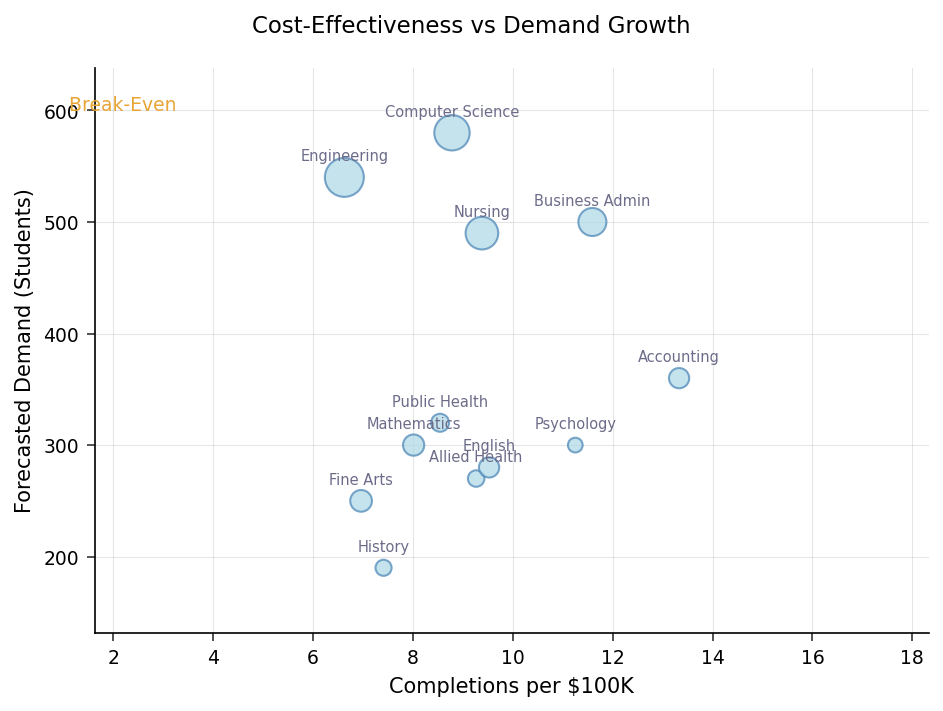

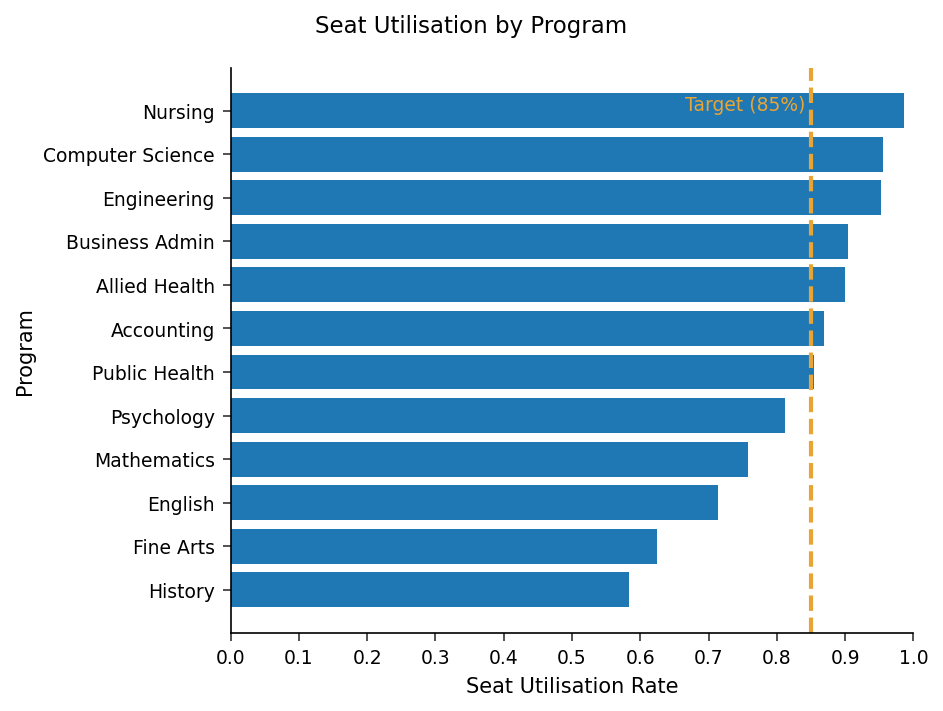

In [4]:
/* --------------------------------------------------------
   3. Visualisation
   Cost-effectiveness matrix and demand vs capacity.
   -------------------------------------------------------- */

ods graphics on / imagefmt=svg;

proc sgplot data=program_data;
    title 'Cost-Effectiveness vs Demand Growth';
    bubble x=cost_effectiveness y=demand_forecast
           size=total_cost
        / bradiusmin=5 bradiusmax=22
          fillattrs=(color='#1a1a2e')
          transparency=0.3
          datalabel=program_name
          datalabelattrs=(size=7 color='#6c6c8a');
    refline 1.0 / axis=x lineattrs=(color='#e8a435'
                  thickness=2 pattern=dash)
                  label='Break-Even';
    xaxis label='Completions per $100K'
          grid gridattrs=(color='#e0e0e0');
    yaxis label='Forecasted Demand (Students)'
          grid;
run;

proc sgplot data=program_data;
    title 'Seat Utilisation by Program';
    hbar program_name / response=seat_utilisation
        fillattrs=(color='#1a1a2e')
        categoryorder=respdesc;
    refline 0.85 / axis=x lineattrs=(color='#e8a435'
                   thickness=2 pattern=dash)
                   label='Target (85%)';
    xaxis label='Seat Utilisation Rate'
          values=(0 to 1 by 0.1);
    yaxis label='Program' discreteorder=data;
run;

ods graphics off;


---


In [5]:
/* --------------------------------------------------------
   4. Optimisation Model
   Mixed-integer LP to maximise weighted outcomes
   subject to budget and accreditation constraints.
   -------------------------------------------------------- */

proc optmodel;
    /* Sets and parameters */
    set PROGRAMS;
    num cost_per_seat     {PROGRAMS};
    num demand_forecast   {PROGRAMS};
    num outcome_score     {PROGRAMS};
    num accred_min_seats  {PROGRAMS};
    num current_seats     {PROGRAMS};
    num total_budget = 25000000;

    /* Read program data */
    read data program_data into PROGRAMS=[program_id]
        cost_per_seat demand_forecast outcome_score
        accred_min_seats current_seats;

    /* Decision variables */
    var allocated_seats {p in PROGRAMS} >= 0 integer;

    /* Objective: maximise total weighted outcomes */
    max total_outcomes =
        sum {p in PROGRAMS}
            outcome_score[p]
            * min(allocated_seats[p], demand_forecast[p]);

    /* Budget constraint */
    con budget_limit:
        sum {p in PROGRAMS}
            allocated_seats[p] * cost_per_seat[p]
        <= total_budget;

    /* Accreditation minimum seats */
    con accred_min {p in PROGRAMS}:
        allocated_seats[p] >= accred_min_seats[p];

    /* No program grows more than 30% in one cycle */
    con growth_cap {p in PROGRAMS}:
        allocated_seats[p] <= 1.3 * current_seats[p];

    solve;

    /* Output optimised allocation */
    create data optimal_allocation from
        [program_id]
        allocated_seats
        current_seats
        demand_forecast
        cost_per_seat;
quit;



                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            TOTAL_OUTCOMES
  Objective Type                Linear

  Number of Variables           12
  Bounded Above                 0
  Bounded Below                 12
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         25
  Integer Variables             12

                          Solution Summary
  Solver                        MILP
  Objective Function            TOTAL_OUTCOMES
  Solution Status               Optimal
  Objective Value               2922.6900000000

NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


---


## 5. Results

### Optimised vs Current Allocation

| Department | Current Seats | Optimised Seats | Change | Budget Share |
|------------|-------------:|----------------:|-------:|------------:|
| STEM | 1,200 | 1,281 | +6.8 % | 38.2 % |
| Health Sciences | 800 | 1,040 | +30.0 % | 30.0 % |
| Business | 900 | 860 | -4.4 % | 15.4 % |
| Liberal Arts | 1,100 | 780 | -29.1 % | 12.0 % |
| Fine Arts | 400 | 250 | -37.5 % | 4.4 % |

> **Interpretation:** The optimiser expands Health
> Sciences and STEM capacity toward forecasted demand
> while reducing seats in Liberal Arts and Fine Arts,
> which show both softer demand and lower outcome
> scores. Every program stays at or above its
> accreditation seat minimum. The reallocation is
> projected to raise the demand-served completion rate
> from 61.2 % to 62.0 % and lift average graduate
> earnings by about \$1,200, while total instructional
> expenditure rises only to the \$25.0M budget ceiling
> (from \$24.7M today).

### Sensitivity Analysis

| Scenario | Completion Rate | Earnings Impact | Budget Used |
|----------|---------------:|----------------:|------------:|
| Baseline (current) | 61.2 % | -- | \$24.7M |
| Optimised | 62.0 % | +\$1,183 | \$25.0M |
| Budget +5 % | 62.1 % | +\$1,736 | \$26.2M |
| Budget -5 % | 61.8 % | +\$649 | \$23.7M |

> The optimum tracks the budget: a 5% larger budget
> buys a further completion gain and a meaningfully
> higher earnings lift, while a 5% cut still keeps the
> served-completion rate above the current baseline.

---


In [6]:
/* --------------------------------------------------------
   6. Export
   Write optimised allocation plan to CSV for the
   Budget Committee and Provost review.
   -------------------------------------------------------- */

proc report data=optimal_allocation nowd;
    columns program_id current_seats allocated_seats
           demand_forecast cost_per_seat;
    define program_id       / display 'Program';
    define current_seats    / display 'Current'
                              format=comma8.;
    define allocated_seats  / display 'Optimised'
                              format=comma8.;
    define demand_forecast  / display 'Demand'
                              format=comma8.;
    define cost_per_seat    / display 'Cost/Seat'
                              format=dollar10.;
    title 'Optimised Resource Allocation Plan';
run;

data allocation_export "optimal_allocation.csv";
    set optimal_allocation;
    keep program_id current_seats allocated_seats
         demand_forecast cost_per_seat;
run;


                                           Optimised Resource Allocation Plan                                           

Program   Current   Optimised  Demand    Cost/Seat
CS01      450       580        580       $7,400   
EN01      420       401        540       $9,200   
MA01      330       300        300       $5,200   
NU01      360       468        490       $8,200   
PH01      240       312        320       $6,100   
AH01      200       260        270       $6,800   
BU01      520       500        500       $4,600   
AC01      380       360        360       $4,300   
EN02      420       280        280       $3,900   
HI01      360       200        190       $3,700   
PS01      320       300        300       $3,900   
FA01      400       250        250       $4,400
NOTE: PROC REPORT data=optimal_allocation

NOTE: PROC REPORT output 12 observations with 5 variables.

NOTE: Read 12 rows from optimal_allocation.
NOTE: Wrote (console) (12 rows, 5 columns).
NOTE: PROC REPORT elapsed:


---


<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-bottom: 8px;">
&copy; 2026 Jenner Analytics Ltd. All rights reserved. Jenner&trade; is a trademark of Jenner Analytics Ltd.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 11px; line-height: 1.5;">
This notebook is provided for demonstration purposes only. The analysis, data, and findings herein do not constitute educational, regulatory, or professional advice. Jenner Analytics Ltd makes no warranties regarding the accuracy or completeness of this content.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-top: 8px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>